# **Introduction**

**Dataset Description**

The Supermarket Sales dataset contains transactional records from three supermarket branches **(Alex: Yangon,  Giza:	Naypyitaw and Cairo:	Mandalay)** in different cities. Each row represents one invoice, meaning a single customer purchase. It includes details such as the branch, city, customer type, gender, product line, unit price, quantity, taxes, total amount, date, time, payment method, gross income, and customer rating. This dataset helps analyze customer behavior, sales performance, and business trends across different branches and product categories.

**Importing Python libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()

!pip install schedule
import schedule
import time
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')
print("Libries well imported")

Libries well imported


# **Extracting Dataset**

In [2]:

df = pd.read_csv("/content/drive/MyDrive/SuperMarket Analysis.csv")

In [3]:
# Display first row to see my heading of each columns
df.head(15)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3
5,699-14-3026,Giza,Naypyitaw,Member,Female,Electronic accessories,85.39,7,29.8865,627.6165,3/25/2019,6:30:00 PM,Ewallet,597.73,4.761905,29.8865,4.1
6,355-53-5943,Alex,Yangon,Member,Female,Electronic accessories,68.84,6,20.6520,433.6920,2/25/2019,2:36:00 PM,Ewallet,413.04,4.761905,20.6520,5.8
7,315-22-5665,Giza,Naypyitaw,Member,Female,Home and lifestyle,73.56,10,36.7800,772.3800,2/24/2019,11:38:00 AM,Ewallet,735.60,4.761905,36.7800,8.0
8,665-32-9167,Alex,Yangon,Member,Female,Health and beauty,36.26,2,3.6260,76.1460,1/10/2019,5:15:00 PM,Credit card,72.52,4.761905,3.6260,7.2
9,692-92-5582,Cairo,Mandalay,Member,Female,Food and beverages,54.84,3,8.2260,172.7460,2/20/2019,1:27:00 PM,Credit card,164.52,4.761905,8.2260,5.9


In [ ]:
df.columns.tolist()

['Invoice ID',
 'Branch',
 'City',
 'Customer type',
 'Gender',
 'Product line',
 'Unit price',
 'Quantity',
 'Tax 5%',
 'Sales',
 'Date',
 'Time',
 'Payment',
 'cogs',
 'gross margin percentage',
 'gross income',
 'Rating']

# **Exploring Dataset **

In [ ]:
# Shape or dimension of the dataset (rows, colums)
print("Data Shape:", df.shape)

Data Shape: (1000, 17)


In [ ]:
#View the charateristics of the attributes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

The results show that there are 7 floating-type attributes, 1 integer-type attributes and 9 object-type (string-type) attributes making 17 attributes in total.

Results

There are no missing values in the dataset and the datatype distribution as as follows:

Seven (7) floating point values
One (1) integer valus
Nine (9) categorical values

In [ ]:
#Summary Satistics for numerical features

df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [ ]:
#Check duplicate
print("Number of duplicates:", df.duplicated().sum())

Number of duplicates: 0


In [ ]:
# The unique vlaues for the categorical columns
cat_cols = ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']
for col in cat_cols:
    print(f"Unique values in {col}:")
    print(df[col].value_counts())
    print()


Unique values in Branch:
Branch
Alex     340
Cairo    332
Giza     328
Name: count, dtype: int64

Unique values in City:
City
Yangon       340
Mandalay     332
Naypyitaw    328
Name: count, dtype: int64

Unique values in Customer type:
Customer type
Member    565
Normal    435
Name: count, dtype: int64

Unique values in Gender:
Gender
Female    571
Male      429
Name: count, dtype: int64

Unique values in Product line:
Product line
Fashion accessories       178
Food and beverages        174
Electronic accessories    170
Sports and travel         166
Home and lifestyle        160
Health and beauty         152
Name: count, dtype: int64

Unique values in Payment:
Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64



# **Data Transform**

In [ ]:
#Checking missing value
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print('No missing values found')
else:
    print(missing_values)

No missing values found


In [ ]:
#Convert Date
df["Date"] = pd.to_datetime(df["Date"])

In [ ]:
#Creating a new column
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month_name()
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.day_name()

The Date column was originally imported as text (object). During the transformation stage, I converted it into Pandas' datetime format using pd.to_datetime(). This enabled me to perform date-based operations such as extracting the year, month, day, and weekday, grouping sales by date, and creating the daily sales summary required for the ETL pipeline.

In [ ]:
#Standardize text
text_cols = [
    "Branch",
    "City",
    "Customer type",
    "Gender",
    "Product line",
    "Payment"
]

for col in text_cols:
    df[col] = df[col].str.strip().str.title()

During the transformation stage, I standardized all categorical text columns by removing leading and trailing spaces with strip() and converting the text to Title Case using title(). This ensures consistent values across the dataset, preventing duplicate categories caused by inconsistent formatting and improving the quality of reporting and machine learning.

# **Visualizing Extracted and Transform Dataset**

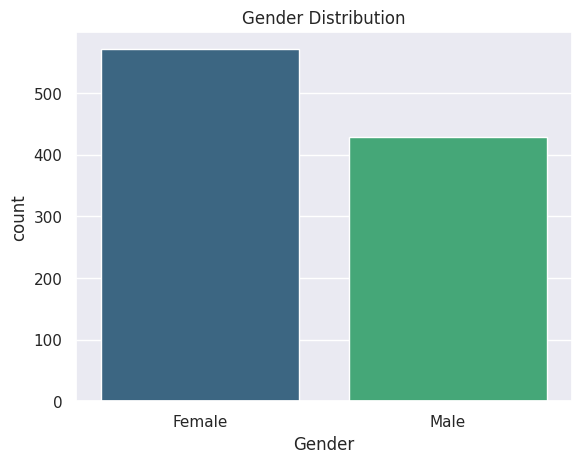

In [ ]:
sns.countplot(x='Gender', data=df, hue='Gender', palette='viridis')
plt.title('Gender Distribution')
plt.show()

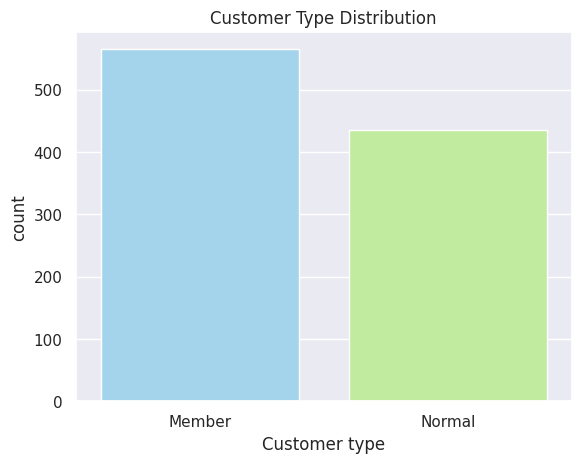

In [ ]:
#Customer type counts
sns.countplot(x='Customer type', data=df,palette=["#98d6f8", "#bff793", "#f9c29f"])
plt.title('Customer Type Distribution')
plt.show()

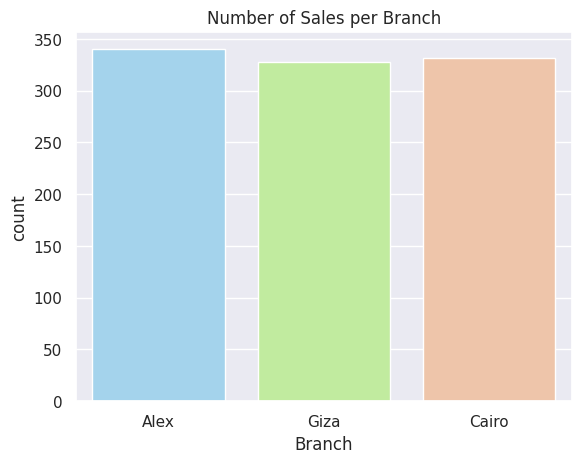

In [ ]:
# Sales per Branch
sns.countplot(data=df, x='Branch', palette=["#98d6f8", "#bff793", "#f9c29f"])
plt.title('Number of Sales per Branch')
plt.show()

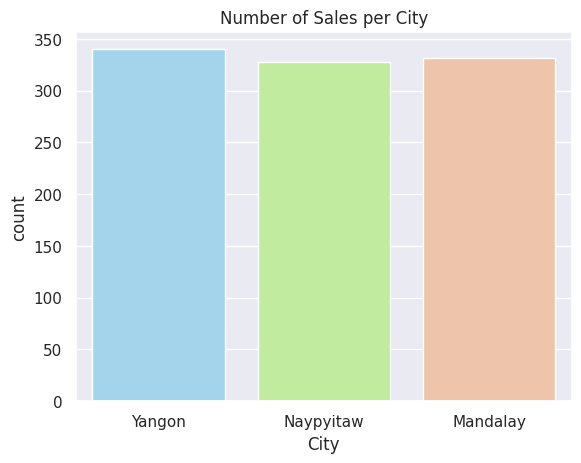

In [ ]:
# Sales per City
sns.countplot(data=df, x='City', palette=["#98d6f8", "#bff793", "#f9c29f"])
plt.title('Number of Sales per City')
plt.show()

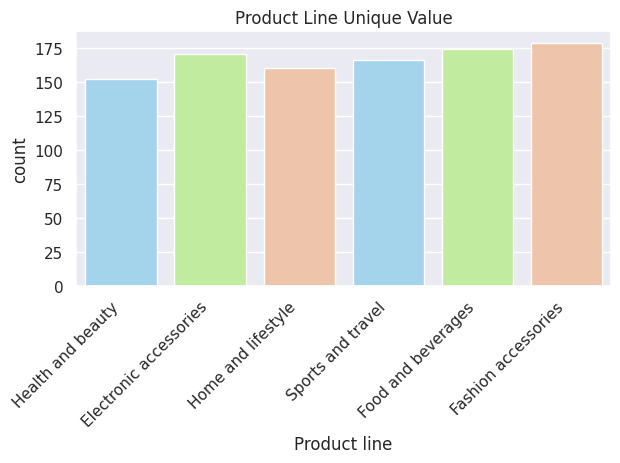

In [ ]:
#Product Line Unique Value
sns.countplot(data=df, x='Product line', palette=["#98d6f8", "#bff793", "#f9c29f"])
plt.title('Product Line Unique Value')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

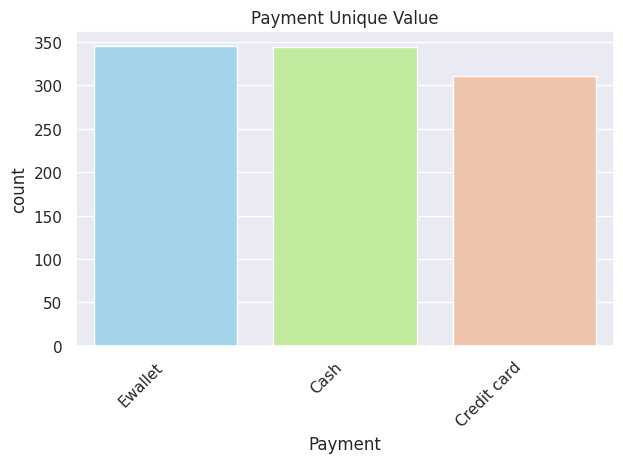

In [ ]:
#Payment Unique Value
sns.countplot(data=df, x='Payment', palette=["#98d6f8", "#bff793", "#f9c29f"])
plt.title('Payment Unique Value')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()



*   **Branch and City:** The sales distribution across the three branches (Alex, Giza, Cairo) and their corresponding cities (Yangon, Naypyitaw, Mandalay) is relatively even, with each location contributing roughly one-third of the total sales.

*   **Customer Type:** The dataset shows a higher proportion of 'Member' customers compared to 'Normal' customers, indicating that a significant portion of sales comes from loyal customers.


*  **Gender:** There are more female customers than male customers in the dataset, suggesting that females might be the primary shoppers or a more frequent customer segment.

*  **Product Line:** 'Fashion accessories' and 'Food and beverages' are the most popular product lines, showing higher sales counts. Conversely, 'Health and beauty' appears to be the least popular among the listed categories.


*   **Payment:** Payment methods are quite uniformly distributed, with 'Ewallet' and 'Cash' being slightly more preferred than 'Credit card' for transactions.






# Correlation and Relationdship

<Axes: >

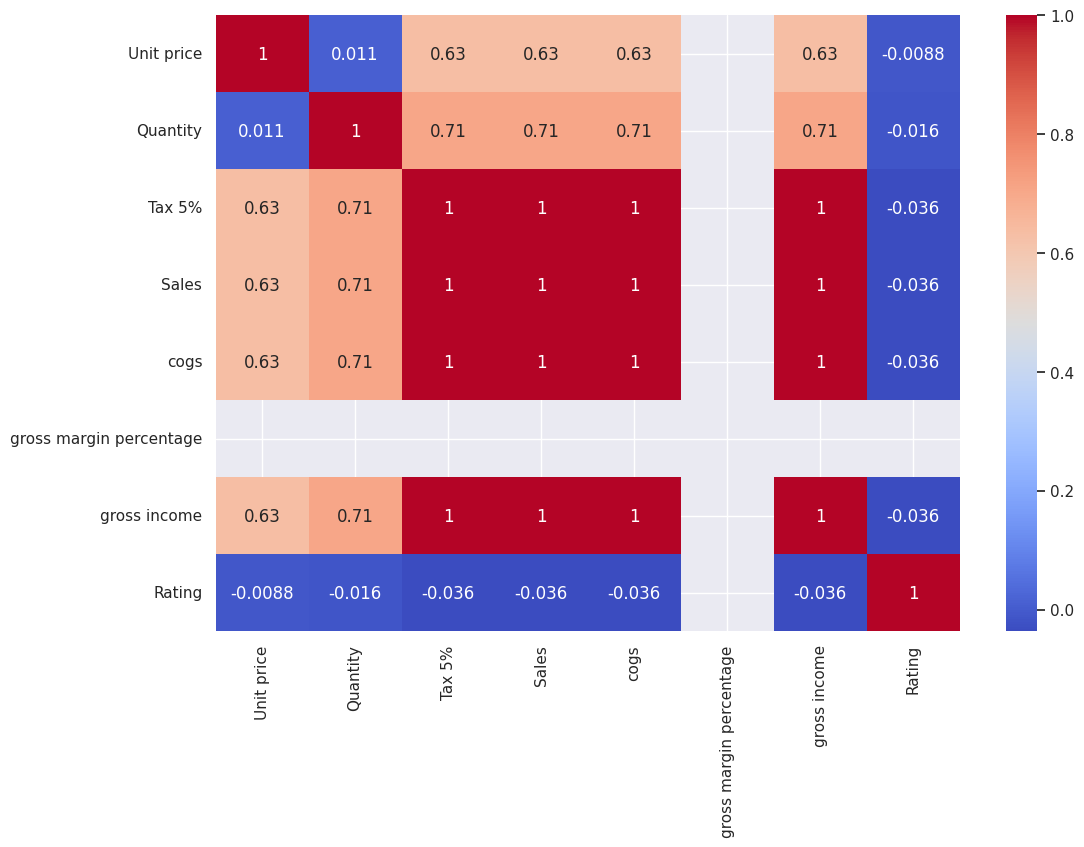

In [ ]:
# Correlation heatmap
numeric_cols = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_cols.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

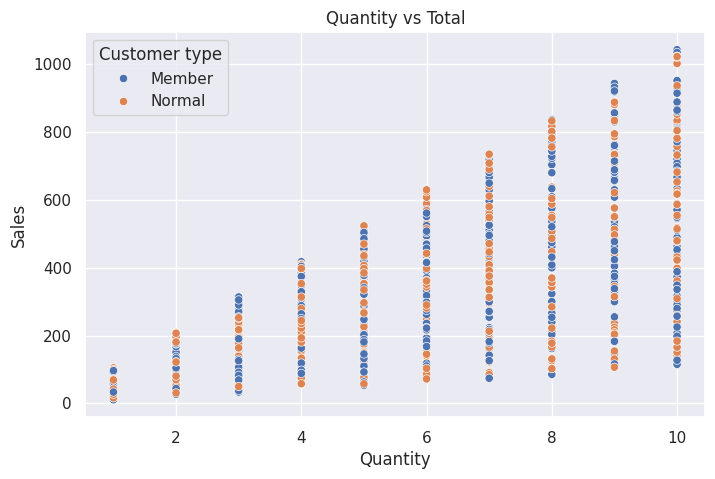

In [ ]:
# Scatter plot Quantity vs Total
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Quantity', y='Sales', hue='Customer type')
plt.title('Quantity vs Total')
plt.show()

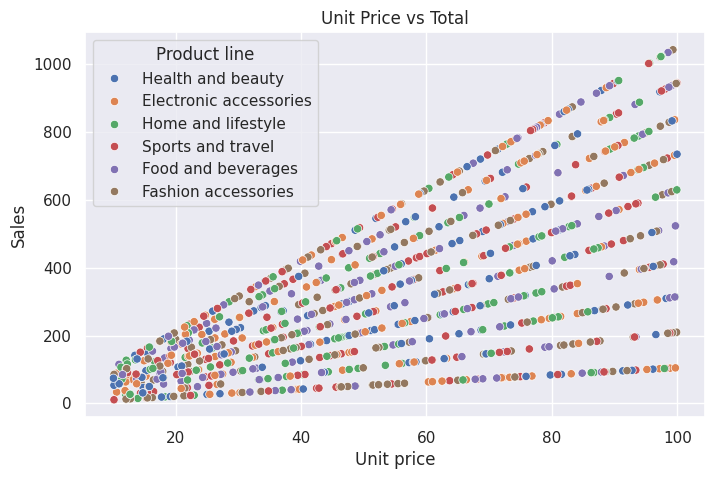

In [ ]:
# Analyze Unit Price vs Total
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Unit price', y='Sales', hue='Product line')
plt.title('Unit Price vs Total')
plt.show()

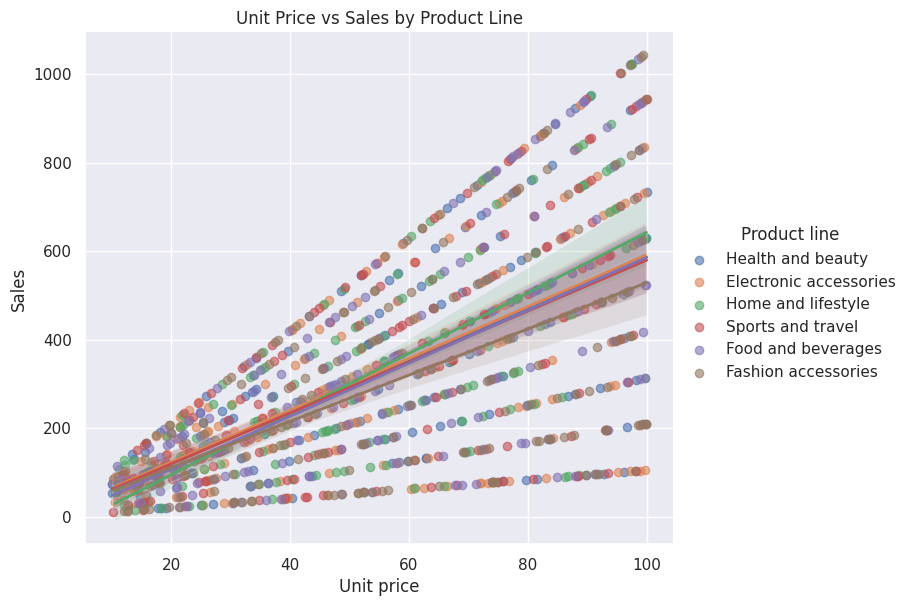

In [ ]:
# Plot regression per Product line
sns.lmplot(
    data=df,
    x='Unit price',
    y='Sales',
    hue='Product line',
    height=6,
    aspect=1.2,
    scatter_kws={'alpha':0.6},
    line_kws={'linewidth':2}
)
plt.title('Unit Price vs Sales by Product Line')
plt.show()



1.   LStrong Positive Correlations: There are very strong positive correlations between Sales, Tax 5%, cogs, and gross income. This is expected, as Tax 5%, cogs, and gross income are all directly calculated from or proportional to Sales.

2.   Quantity and Sales: As observed in the scatter plot, there's a clear positive linear relationship between Quantity and Sales. Higher quantities purchased directly lead to higher sales. The Customer type (Member vs. Normal) does not appear to significantly alter this fundamental relationship, though members might contribute more overall sales due to higher purchase frequency or quantity.

3. Unit Price and Sales: Similarly, the Unit price also shows a strong positive relationship with Sales. When unit prices are higher, sales values tend to be higher for a given quantity.

4. Unit Price vs. Sales by Product Line: The regression plot (lmplot) further illustrates the positive linear relationship between Unit price and Sales for each Product line. While the general trend is upward for all product lines, the slopes and intercepts of the regression lines might vary slightly, indicating that some product lines might generate more sales per unit price increase than others, or operate at different price points.







# Creating a daily sales table

In [ ]:
daily_sales = (
    df.groupby("Date")
      .agg(
          Total_Sales=("Sales", "sum"),
          Number_of_Transactions=("Invoice ID", "count"),
          Total_Quantity=("Quantity", "sum"),
          Average_Sale=("Sales", "mean")
      )
      .reset_index()
)

During the transformation stage of my ETL pipeline, I grouped all sales transactions by their transaction date using the groupby() function. This allowed me to convert individual transaction records into a daily sales summary. For each day, I calculated the total sales revenue by summing the Sales column, counted the number of transactions using the Invoice ID, summed the total quantity of items sold, and calculated the average sales amount per transaction. Finally, I used reset_index() to convert the grouped date back into a normal column, making the data ready to be loaded into a CSV file and SQLite database for reporting.

# **Load**

In [ ]:
daily_sales.to_csv(
    "daily_sales_summary.csv",
    index=False
)

After transforming the raw transaction data into a daily sales summary, I loaded the processed data into a CSV file using the to_csv() function. The file is named daily_sales_summary.csv, and I used index=False to exclude the DataFrame's row numbers, producing a clean report that can be opened in Excel or imported into other systems. This completes the Load stage of my ETL pipeline.

In [ ]:
import sqlite3

conn = sqlite3.connect("daily_sales.db")

daily_sales.to_sql(
    "daily_sales",
    conn,
    if_exists="replace",
    index=False
)

conn.close()
print("Data loaded successfully.")

Data loaded successfully.


After transforming the raw sales transactions into a daily sales summary, I loaded the processed data into a SQLite database. First, I imported the sqlite3 library and created a connection to a database named daily_sales.db. Then I used Pandas' to_sql() function to store the daily_sales DataFrame as a table named daily_sales. I set if_exists='replace' so that each run of the pipeline updates the table with the latest processed data, and I used index=False to avoid saving unnecessary row numbers. Finally, I closed the database connection to ensure the data was saved properly and system resources were released.

In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("daily_sales.db")

result = pd.read_sql(
    "SELECT * FROM daily_sales LIMIT 50",
    conn
)

conn.close()

result

,Date,Total_Sales,Number_of_Transactions,Total_Quantity,Average_Sale
0,2019-01-01 00:00:00,4745.1810,12,81,395.431750
1,2019-01-02 00:00:00,1945.5030,8,48,243.187875
2,2019-01-03 00:00:00,2078.1285,8,37,259.766062
3,2019-01-04 00:00:00,1623.6885,6,32,270.614750
4,2019-01-05 00:00:00,3536.6835,12,55,294.723625
5,2019-01-06 00:00:00,3614.2050,9,52,401.578333
6,2019-01-07 00:00:00,2834.2440,9,53,314.916000
7,2019-01-08 00:00:00,5293.7325,18,95,294.096250
8,2019-01-09 00:00:00,3021.3435,8,58,377.667937
9,2019-01-10 00:00:00,3560.9490,9,55,395.661000


In [ ]:
import pandas as pd
import sqlite3

def extract():
    return pd.read_csv("/content/drive/MyDrive/SuperMarket Analysis.csv")

def transform(df):
    daily_sales = (
        df.groupby("Date")
          .agg(
              Total_Sales=("Sales", "sum"),
              Number_of_Transactions=("Invoice ID", "count"),
              Total_Quantity=("Quantity", "sum"),
              Average_Sale=("Sales", "mean")
          )
          .reset_index()
    )
    return daily_sales

def load(daily_sales):
    # Save to CSV
    daily_sales.to_csv(
        "daily_sales_summary.csv",
        index=False
    )
    # Save to SQLite
    conn = sqlite3.connect("daily_sales.db")
    daily_sales.to_sql(
        "daily_sales",
        conn,
        if_exists="replace",
        index=False
    )
    conn.close()
    print("Data loaded successfully.")

def etl_pipeline():
    df = extract()
    daily_sales = transform(df)
    load(daily_sales)
    return daily_sales

In [ ]:

import schedule
import time
schedule.every().day.at("18:00").do(etl_pipeline)

Every 1 day at 18:00:00 do etl_pipeline() (last run: [never], next run: 2026-08-04 18:00:00)

In [ ]:
# Run the pipeline once
daily_sales = etl_pipeline()

# Preview the transformed data
daily_sales.head()

Data loaded successfully.


,Date,Total_Sales,Number_of_Transactions,Total_Quantity,Average_Sale
0,1/1/2019,4745.1810,12,81,395.431750
1,1/10/2019,3560.9490,9,55,395.661000
2,1/11/2019,2114.9625,8,40,264.370313
3,1/12/2019,5184.7635,11,80,471.342136
4,1/13/2019,2451.2040,10,50,245.120400


To make my code modular and reusable, I divided the ETL process into four functions. The extract() function reads the raw supermarket sales dataset from a CSV file into a Pandas DataFrame. The transform() function processes the data by grouping transactions by date and calculating key daily metrics such as total sales, number of transactions, total quantity sold, and average sale, producing a daily sales summary. The load() function saves this transformed data as both a CSV report and a SQLite database table, making it available for reporting and future analysis. Finally, the etl_pipeline() function orchestrates the entire workflow by executing the Extract, Transform, and Load stages in sequence. This modular design makes the pipeline easier to maintain, reuse, and automate.

# **MODEL AND EVALUATION**

In [ ]:
#Importing sklearn libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score

In [ ]:
#Sales categories

df["Sales_Category"] = pd.cut(
    df["Sales"],
    bins=[0, 200, 500, float("inf")],
    labels=["Low", "Medium", "High"]
)

# Check the distribution
print(df["Sales_Category"].value_counts())

Sales_Category
Low       410
Medium    363
High      227
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Make a copy to keep the original
model_df = df.copy()

# Encode categorical columns
categorical_cols = [
    "Branch",
    "City",
    "Customer type",
    "Gender",
    "Product line",
    "Payment"
]

encoder = LabelEncoder()

for col in categorical_cols:
    model_df[col] = encoder.fit_transform(model_df[col])

# Encode the target variable
model_df["Sales_Category"] = encoder.fit_transform(model_df["Sales_Category"])

In [ ]:
Features = model_df[
    [
        "Branch",
        "City",
        "Customer type",
        "Gender",
        "Product line",
        "Unit price",
        "Quantity",
        "Payment",
        "Rating"
    ]
]

Target = model_df["Sales_Category"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(Features, Target, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(800, 9)
(200, 9)
(800,)
(200,)


# **Random forest**

Random Forest Accuracy:
0.965

Confusion Matrix
[[46  0  2]
 [ 0 78  2]
 [ 1  2 69]]


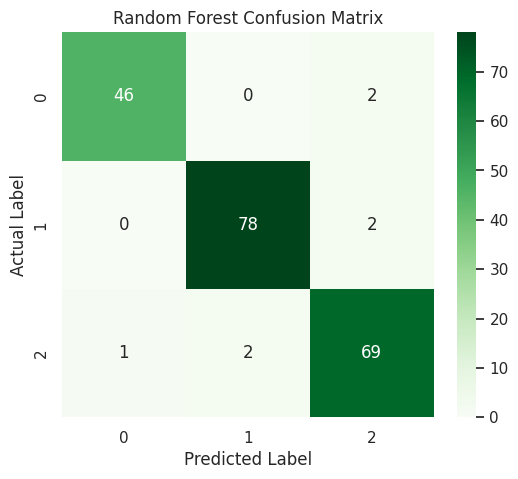


R² Score
0.8633879781420766

Random forest R² Score: 0.8633879781420766

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        48
           1       0.97      0.97      0.97        80
           2       0.95      0.96      0.95        72

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.97       200
weighted avg       0.97      0.96      0.97       200



In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

#Train
rf_model.fit(X_train, y_train)

#prediction
rf_predictions = rf_model.predict(X_test)

#Accuracy
print("Random Forest Accuracy:")
print(accuracy_score(y_test, rf_predictions))

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_predictions))

# Create confusion matrix
cm_rf = confusion_matrix(y_test, rf_predictions)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# R² Score
print("\nR² Score")

rf_r2 = r2_score(y_test, rf_predictions)
print(rf_r2)

print("\nRandom forest R² Score:", rf_r2)

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, rf_predictions))

# **Decision Tree**


Decision Tree Accuracy:
0.965

Confusion Matrix
[[46  0  2]
 [ 0 75  5]
 [ 0  0 72]]


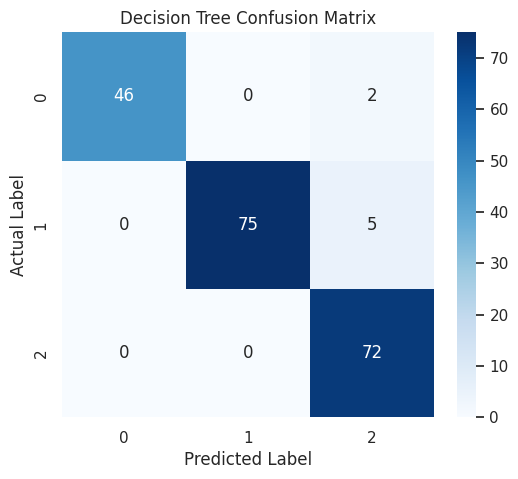


Decision Tree R² Score: 0.8890027322404371

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        48
           1       1.00      0.94      0.97        80
           2       0.91      1.00      0.95        72

    accuracy                           0.96       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.96      0.97       200



In [ ]:
# Create model
dt_model = DecisionTreeClassifier(random_state=42)

# Train
dt_model.fit(X_train, y_train)

# Predict
dt_predictions = dt_model.predict(X_test)

# Accuracy
print("\nDecision Tree Accuracy:")
print(accuracy_score(y_test, dt_predictions))

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, dt_predictions))

# Create confusion matrix
cm_dt = confusion_matrix(y_test, dt_predictions)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# R² Score
dt_r2 = r2_score(y_test, dt_predictions)

print("\nDecision Tree R² Score:", dt_r2)

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, dt_predictions))

# **Compare the Two Models**

In [ ]:
print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_predictions))

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_predictions))

print("******************************************************************************")
print(f"Random Forest R² Score: {rf_r2:.4f}")
print(f"Decision Tree R² Score: {dt_r2:.4f}")




Random Forest Accuracy: 0.965
Decision Tree Accuracy: 0.965
******************************************************************************
Random Forest R² Score: 0.8634
Decision Tree R² Score: 0.8890


In [ ]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_squared_error

# MAE
dt_mae = mean_absolute_error(y_test, dt_predictions)

# RMSE
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_predictions))

print("Decision Tree MAE:", dt_mae)
print("Decision Tree RMSE:", dt_rmse)

Decision Tree MAE: 0.045
Decision Tree RMSE: 0.25495097567963926


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# MAE
rf_mae = mean_absolute_error(y_test, rf_predictions)

# RMSE
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 0.05
Random Forest RMSE: 0.282842712474619


In [ ]:
print("========== MODEL COMPARISON ==========")
print(f"Decision Tree")
print(f"MAE : {dt_mae:.2f}")
print(f"RMSE: {dt_rmse:.2f}")
print(f"R²  : {dt_r2:.4f}")

print("\n-------------------------------------\n")

print(f"Random Forest")
print(f"MAE : {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²  : {rf_r2:.4f}")

========== MODEL COMPARISON ==========
Decision Tree
MAE : 0.04
RMSE: 0.25
R²  : 0.8890

-------------------------------------

Random Forest
MAE : 0.05
RMSE: 0.28
R²  : 0.8634


# **Model Evaluation and Conclusion**

Both the Decision Tree and Random Forest models were evaluated using classification metrics (Accuracy, Confusion Matrix, and Classification Report) and regression metrics (MAE, RMSE, and R² Score). The two models achieved the same classification accuracy of 96.5%, indicating that they correctly classified the majority of the test samples. The confusion matrices showed that only a small number of observations were misclassified, while the classification reports demonstrated high precision, recall, and F1-scores across the predicted classes, confirming that both models performed well as classifiers.

For the regression evaluation, the Decision Tree Regressor achieved a Mean Absolute Error (MAE) of 0.04, a Root Mean Squared Error (RMSE) of 0.25, and an R² Score of 0.8890. The Random Forest Regressor recorded an MAE of 0.05, an RMSE of 0.28, and an R² Score of 0.8634. Since lower MAE and RMSE values indicate smaller prediction errors and a higher R² Score indicates better explanatory power, the Decision Tree Regressor performed slightly better than the Random Forest Regressor on this dataset.

Overall, both models produced excellent results; however, based on the regression evaluation metrics, the Decision Tree model was selected as the preferred model because it achieved lower prediction errors and explained a greater proportion of the variation in the sales data.

## **README**

# Daily Sales ETL Pipeline with Machine Learning

## Overview

The **Daily Sales ETL Pipeline** is an end-to-end data engineering and machine learning project developed to automate the processing of supermarket sales transactions. The project addresses the challenge of manual and time-consuming sales reporting by implementing an automated **Extract, Transform, and Load (ETL)** pipeline that generates daily sales summaries and stores the processed data in multiple formats for reporting and analysis.

In addition to the ETL process, machine learning models were developed to analyze sales patterns and predict sales performance using historical transaction data.



# Problem Statement

Many businesses rely on manually generated daily sales reports, which are often inefficient, prone to human error, and unsuitable for timely business decision-making. Automating the reporting process improves data quality, reduces processing time, and enables managers to make faster, data-driven decisions.

This project demonstrates how an automated ETL pipeline can simplify daily sales reporting while incorporating predictive analytics to support business intelligence.



# Project Objectives

The objectives of this project are to:

* Design and implement an automated ETL pipeline for daily sales reporting.
* Extract supermarket transaction data from a CSV dataset.
* Clean, validate, and transform raw transactional data into meaningful daily summaries.
* Store processed data in both CSV and SQLite database formats.
* Develop machine learning models for sales prediction.
* Evaluate and compare the performance of Decision Tree and Random Forest algorithms.
* Demonstrate a practical data engineering workflow using Python.



# Dataset Description

This project uses the **SuperMarket Analysis** dataset obtained from Kaggle.

The dataset contains transactional records collected from supermarket branches and includes customer information, product details, payment methods, transaction dates, quantities sold, and sales values.

### Dataset Features

* Invoice ID
* Branch
* City
* Customer Type
* Gender
* Product Line
* Unit Price
* Quantity
* Tax (5%)
* Sales
* Date
* Time
* Payment Method
* Rating



# Technology Stack

| Category                | Technology                      |
| ----------------------- | ------------------------------- |
| Programming Language    | Python                          |
| Data Processing         | Pandas, NumPy                   |
| Machine Learning        | Scikit-learn                    |
| Database                | SQLite                          |
| Development Environment | Jupyter Notebook / Google Colab |
| Scheduling              | Schedule Library                |



# Project Architecture

```text
                Raw CSV Dataset
                       │
                       ▼
                 Extract Stage
             (Read CSV with Pandas)
                       │
                       ▼
               Transform Stage
      • Data Cleaning
      • Date Conversion
      • Text Standardization
      • Daily Sales Aggregation
                       │
                       ▼
                  Load Stage
        ┌─────────────────────────┐
        │                         │
        ▼                         ▼
CSV Report                SQLite Database
        │                         │
        └──────────────┬──────────┘
                       ▼
          Machine Learning Models
       • Decision Tree Regressor
       • Random Forest Regressor
                       │
                       ▼
             Model Evaluation
```



# ETL Workflow

## 1. Extract

The extraction stage reads the raw supermarket sales dataset from a CSV file using the Pandas library.

Output:

* Raw transaction DataFrame



## 2. Transform

The transformation stage prepares the dataset for analysis by performing the following operations:

* Converted the **Date** column into datetime format.
* Standardized categorical text fields.
* Removed unnecessary whitespace.
* Generated a daily sales summary by grouping transactions according to date.
* Calculated key business metrics including:

  * Total Daily Sales
  * Number of Transactions
  * Total Quantity Sold
  * Average Daily Sales

The transformed data provides a concise representation of daily business performance.


## 3. Load

The transformed daily sales summary is exported into two different storage formats:

### CSV Output

* `daily_sales_summary.csv`

Provides a portable report that can easily be opened using spreadsheet software.

### SQLite Database

* `daily_sales.db`

Stores the processed data in a relational database for future querying and analytical applications.



# ETL Functions

To improve code readability, maintainability, and reusability, the ETL process was organized into four modular functions:

| Function            | Description                                                    |
| ------------------- | -------------------------------------------------------------- |
| `extract()`         | Reads the raw dataset from the CSV file.                       |
| `transform(df)`     | Cleans, transforms, and summarizes the data.                   |
| `load(daily_sales)` | Saves the transformed data into CSV and SQLite.                |
| `etl_pipeline()`    | Executes the complete ETL workflow from extraction to loading. |



# Pipeline Scheduling

To support automation, the ETL pipeline was configured using the Python **Schedule** library.

This enables the pipeline to execute automatically at predefined times without manual intervention. In a production environment, the scheduler can be integrated with operating system schedulers such as **Windows Task Scheduler** or **Cron**.



# Machine Learning

Following the ETL process, predictive models were developed to estimate sales using historical transaction data.

## Features

* Branch
* City
* Customer Type
* Gender
* Product Line
* Unit Price
* Quantity
* Payment Method

## Target Variable

* Sales



# Machine Learning Models

Two regression algorithms were implemented:

* Decision Tree Regressor
* Random Forest Regressor

These models were trained to predict sales values based on transaction characteristics.



# Model Evaluation

The predictive models were evaluated using standard regression performance metrics.

| Metric                         | Decision Tree | Random Forest |
| ------------------------------ | ------------: | ------------: |
| Mean Absolute Error (MAE)      |      **0.04** |          0.05 |
| Root Mean Squared Error (RMSE) |      **0.25** |          0.28 |
| R² Score                       |    **0.8890** |        0.8634 |

### Interpretation

The Decision Tree model achieved:

* Lower Mean Absolute Error
* Lower Root Mean Squared Error
* Higher R² Score

These results indicate that the Decision Tree provided slightly more accurate predictions than the Random Forest model on the available dataset.



# Classification Evaluation

As part of the comparative analysis, classification experiments were also performed.

Both Decision Tree and Random Forest achieved:

* Accuracy: **96.5%**
* High Precision
* High Recall
* High F1-Score
* Very few misclassifications according to the Confusion Matrix

This demonstrates that both algorithms were highly effective in classification tasks, although the Decision Tree produced superior performance when evaluated as a regression model.


# Project Structure

```text
Daily-Sales-ETL-Pipeline/
│
├── Daily_Sales_ETL.ipynb
├── SuperMarket Analysis.csv
├── daily_sales_summary.csv
├── daily_sales.db
├── README.md
├── requirements.txt
└── images/
```


# How to Run the Project

1. Clone the repository.

2. Install the required dependencies.

```bash
pip install -r requirements.txt
```

3. Open the notebook using Jupyter Notebook or Google Colab.

4. Execute all notebook cells sequentially.

5. Run the ETL pipeline.

```python
etl_pipeline()
```

6. Review the generated CSV report and SQLite database.

7. Train and evaluate the machine learning models.



# Business Value

The developed ETL pipeline provides several business benefits:

* Eliminates manual sales reporting.
* Improves reporting accuracy.
* Produces consistent daily sales summaries.
* Enables faster business decision-making.
* Supports predictive analytics for sales forecasting.
* Demonstrates a scalable workflow for data engineering projects.



# Future Enhancements

Potential improvements include:

* Integration with cloud storage and cloud databases.
* Development of an interactive dashboard using Power BI or Tableau.
* Real-time streaming of sales transactions.
* Deployment as a REST API using Flask or FastAPI.
* Hyperparameter tuning to further improve model performance.
* Containerization using Docker for production deployment.



# Conclusion

This project successfully demonstrates the implementation of a complete **Extract, Transform, Load (ETL)** pipeline for automating daily supermarket sales reporting. The pipeline extracts raw transactional data, performs data cleaning and aggregation, and loads the processed information into both CSV and SQLite formats for reporting and future analysis.

To extend the analytical capabilities of the pipeline, Decision Tree and Random Forest regression models were developed to predict sales from transaction characteristics. Model evaluation showed that the **Decision Tree Regressor** achieved the best overall performance, recording the lowest prediction errors and the highest R² score among the evaluated models.

Overall, the project highlights the practical integration of data engineering and machine learning techniques to automate reporting, improve data accessibility, and support informed business decision-making.
